In [112]:
%%capture
!pip install ydata-profiling

In [118]:
# Jupyter magic command to display plots inline
%matplotlib inline

# Import essential data science libraries
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating visualizations
import numpy as np  # For numerical computing

from ydata_profiling import ProfileReport


In [122]:
# Read the CSV file with tab separator
df = pd.read_csv('avocado.csv', sep = '\t')

# Define columns to keep in the dataframe
relevant_columns = ['code', 'lc', 'product_name_en', 'quantity', 'serving_size', 'packaging_tags', 'brands', 'brands_tags', 'categories_tags', 'labels_tags', 'countries', 'countries_tags', 'origins','origins_tags']

# Read relevant avocado categories from text file
with open('relevant_avocado_categories.txt') as file:
    relevant_avocado_categories = file.read().splitlines()
    file.close()

# Filter dataframe to only include relevant columns
df = df[relevant_columns]

# Split category tags string into list
df['categories_tags'] = df['categories_tags'].str.split(',')

# Remove rows with missing category tags
df = df.dropna(subset = 'categories_tags')

# Filter rows to only include those with relevant avocado categories
avocados = df[df['categories_tags'].apply(lambda x: any([i for i in x if i in relevant_avocado_categories]))]

# Display first few rows of processed dataframe
#df.head()
#avocados.head()

profile = ProfileReport(df, title="avocados")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [108]:
avocados_en = avocados[avocados['lc'] == 'en']
##split?

top_avocado_origins = avocados_en['origins_tags'].value_counts()
top_avocado_origins.index = top_avocado_origins.index.str.lstrip('en:')
top_avocado_origins.index = top_avocado_origins.index.str.replace('-', ' ')

print(top_avocado_origins)

origins_tags
peru             4
mexico           3
australia        3
chile            2
spain            1
spain,en:peru    1
united states    1
chile,en:peru    1
colombia         1
w zealand        1
kenia            1
morocco          1
columbia         1
israel           1
Name: count, dtype: int64


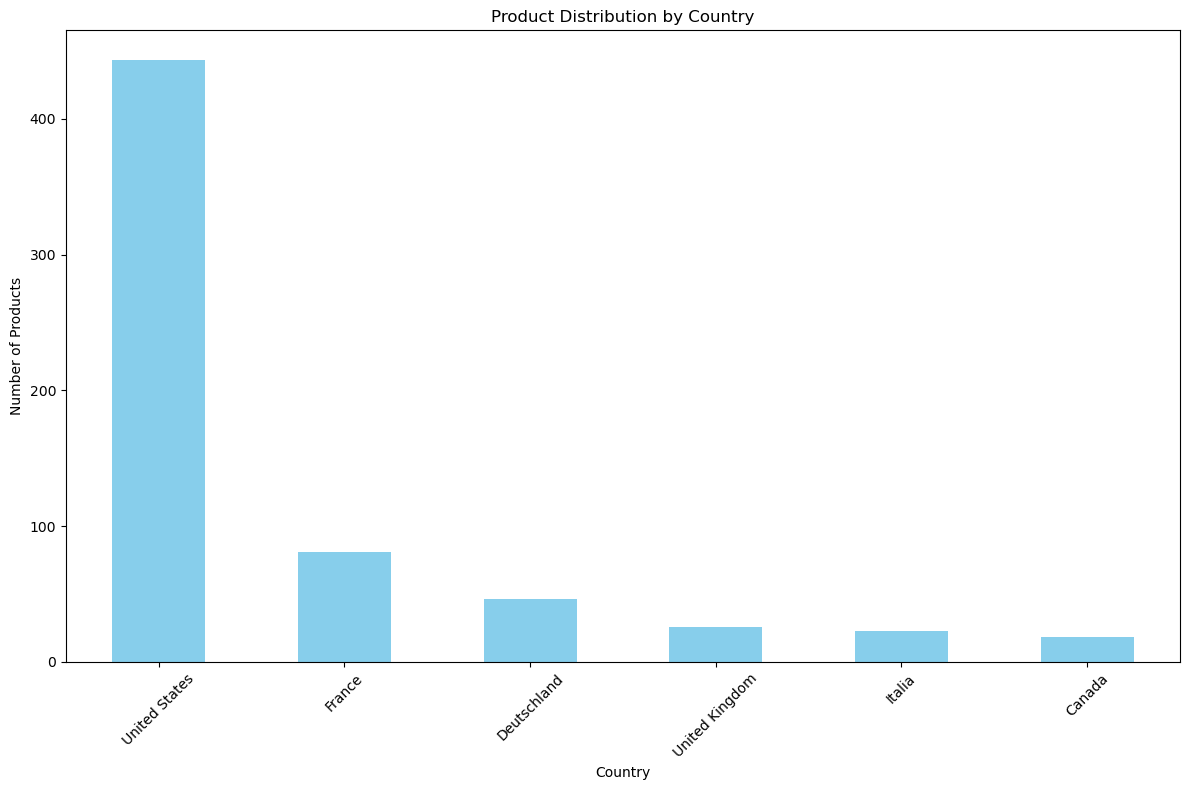

In [88]:
# Count products by country
country_counts = df['countries'].value_counts()[0:6]

# Plotting the bar chart
plt.figure(figsize=(12, 8))
country_counts.plot(kind='bar', color='skyblue')
plt.title('Product Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()